# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# 2. Load Dataset

In [3]:
data = pd.read_csv("HR_Attrition.csv")
data.sample(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1115,34,No,Travel_Rarely,479,Research & Development,7,4,Medical,1,1577,...,3,80,0,1,4,1,1,0,0,0
1302,35,No,Travel_Rarely,185,Research & Development,23,4,Medical,1,1826,...,2,80,1,6,2,4,5,4,0,3
843,26,No,Travel_Rarely,1384,Research & Development,3,4,Medical,1,1177,...,2,80,1,8,2,3,8,7,0,7
913,45,Yes,Travel_Rarely,1449,Sales,2,3,Marketing,1,1277,...,1,80,0,26,2,3,24,10,1,11
589,29,Yes,Travel_Rarely,805,Research & Development,1,2,Life Sciences,1,816,...,4,80,1,1,1,3,1,0,0,0
185,33,No,Travel_Rarely,931,Research & Development,14,3,Medical,1,252,...,4,80,1,8,5,3,8,7,1,6
1051,44,No,Travel_Frequently,383,Sales,1,5,Marketing,1,1481,...,3,80,1,11,4,2,1,0,0,0
338,30,No,Travel_Rarely,570,Sales,5,3,Marketing,1,456,...,3,80,3,10,2,3,10,9,1,2
522,37,No,Travel_Rarely,1225,Research & Development,10,2,Life Sciences,1,715,...,1,80,0,4,2,3,1,0,0,0
1254,49,No,Travel_Rarely,1313,Sales,11,4,Marketing,1,1757,...,3,80,0,8,1,4,5,1,0,4


In [4]:
data.shape

(1470, 35)

In [5]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

# 3. Basic Exploration

In [6]:
data.info() # statical analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
data.describe() # statical analysis

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
data["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
# Attrition rate:
attrition_rate = (
    data["Attrition"].value_counts(normalize=True)*100
)

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


### Only around 16.122449 % of employees left the company while  83.877551% stayed. This indicates an imbalanced dataset. 

In [10]:
# Numeric col
num_cols = data.select_dtypes(include=np.number)

print(num_cols.shape[1])

26


In [11]:
# Categorical columns:
cat_cols = data.select_dtypes(include="object")

print(cat_cols.shape[1])

9


# 4. Missing Values

In [12]:
# checking null values in col
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### No missing values were found.

In [13]:
# checking duplicate values 
data.duplicated().sum()

0

### No duplicated values were found.

# 5. Drop Useless Columns

In [14]:
# droping col that not help in tranning
data.drop(
    columns=[
        "EmployeeNumber",
        "Over18",
        "StandardHours",
        "EmployeeCount"
    ],
    inplace=True
)

### EmployeeNumber col means Unique ID , Over18 is a Same value, StandardHours and EmployeeCount also is a same values.

# 6. Convert Target Variable

In [15]:
data["Attrition"] = data["Attrition"].map({
    "Yes":1,
    "No":0
})

# 7. EDA

In [16]:
# Attrition by Department
dept_attrition = pd.crosstab(
    data["Department"],
    data["Attrition"],
    normalize="index"
)*100

dept_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


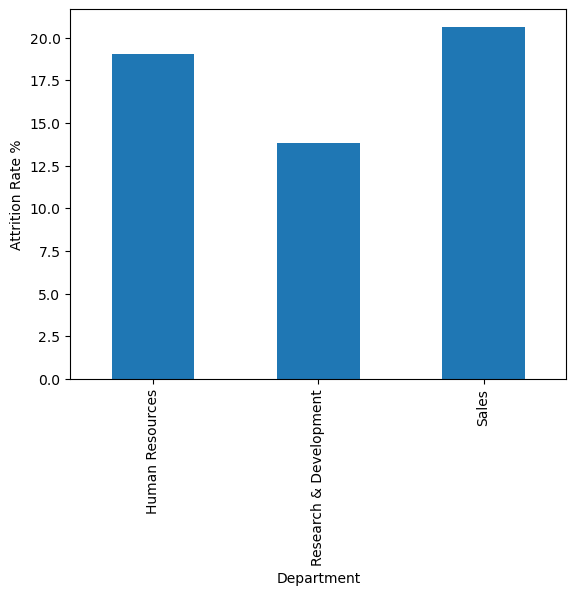

In [17]:
#Visualization
dept_attrition[1].plot(
    kind="bar"
)

plt.ylabel("Attrition Rate %")
plt.savefig("charts/bar plt.png")
plt.show()

### Research & Development has the lowest attrition rate (13.84%), indicating the highest employee retention. In contrast, Sales has the highest attrition rate (20.63%), followed closely by Human Resources (19.05%), suggesting employees leave these departments more frequently.

Attrition                          0          1
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


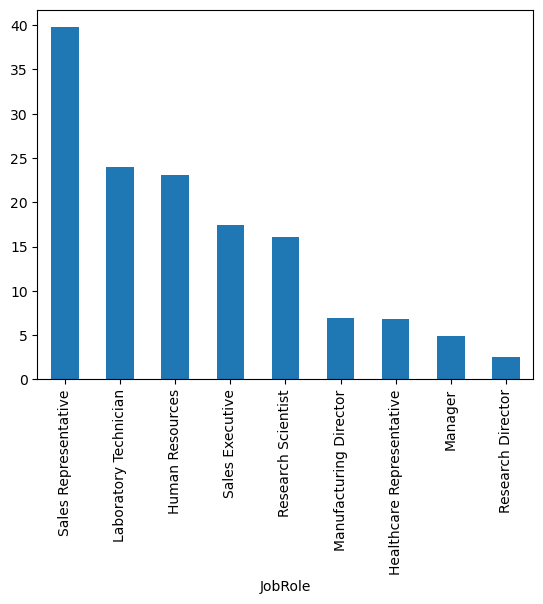

In [18]:
# Attrition by Job Role
role_attrition = pd.crosstab(
    data["JobRole"],
    data["Attrition"],
    normalize="index"
)*100
print(role_attrition)
role_attrition[1].sort_values(
    ascending=False
).plot(kind="bar")
plt.savefig("charts/Attrition by Job Role.png")
plt.show()

### Laboratory Technicians (23.94%) and Human Resources employees (23.08%) have the highest attrition rates, indicating they are more likely to leave the company. In contrast, Research Directors (2.50%) and Managers (4.90%) have the lowest attrition rates, showing the strongest employee retention.

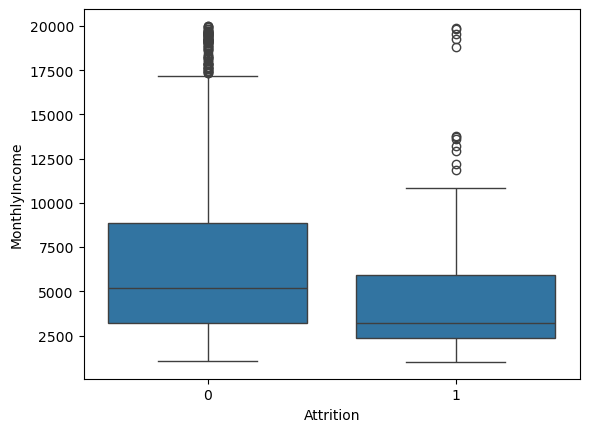

In [19]:
# Monthly Income vs Attrition
sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=data
)
plt.savefig("charts/Monthly Income vs Attrition.png")
plt.show()

### The box plot compares the salary distribution of employees who stayed versus those who left. It helps determine whether salary is associated with employee attrition.

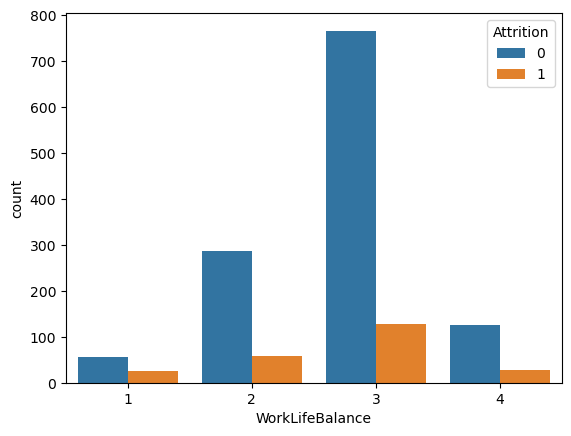

In [20]:
# Work Life Balance
sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition",
    data=data
)
plt.savefig("charts/Work Life Balance.png")
plt.show()

### This chart illustrates how employee attrition varies across different work-life balance ratings, indicating whether poor work-life balance contributes to resignations.

In [ ]:
# Years At Company

sns.histplot(
    data=data,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack"
)
plt.savefig("charts/Years At Company.png")
plt.show()

### his visualization shows when employees are most likely to leave the organization based on their tenure.

In [ ]:
# converting  categorical columns inot numeric columns
df_encoded = pd.get_dummies(
    data,
    columns=data.select_dtypes(include=["object"]).columns,
    drop_first=True
).astype("int")

In [ ]:
df_encoded.sample(5)

# 9. Split Features & Target

In [ ]:
x = df_encoded.drop(
    "Attrition",
    axis=1
)

y = df_encoded["Attrition"]

# 10. Train Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 11. Scaling

In [ ]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

# 12. Logistic Regression

In [ ]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

lr.fit(x_train, y_train)

In [ ]:
lr_pred = lr.predict(x_test)

lr_prob = lr.predict_proba(x_test)[:,1]

# 13. Random Forest

In [ ]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf.fit(x_train,y_train)

rf_pred = rf.predict(x_test)

rf_prob = rf.predict_proba(x_test)[:,1]

# 14. Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(x_train,y_train)

gb_pred = gb.predict(x_test)

gb_prob = gb.predict_proba(x_test)[:,1]

# 15. Evaluation Function

In [ ]:
def evaluate_model(
    y_true,
    y_pred,
    y_prob,
    model_name
):

    print(model_name)

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    print(
        "ROC AUC:",
        roc_auc_score(
            y_true,
            y_prob
        )
    )

In [ ]:
evaluate_model(
    y_test,
    lr_pred,
    lr_prob,
    "Logistic Regression"
)

evaluate_model(
    y_test,
    rf_pred,
    rf_prob,
    "Random Forest"
)

evaluate_model(
    y_test,
    gb_pred,
    gb_prob,
    "Gradient Boosting"
)

# 16. Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC_AUC":[
        roc_auc_score(y_test,lr_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,gb_prob)
    ]
})

comparison

# 17. Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.savefig("charts/Confusion Matrix.png")
plt.show()

### The confusion matrix summarizes the classification performance by showing correct and incorrect predictions for employees who stayed and those who left.

# 18. Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature":x.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

In [ ]:
# plot 
top10 = importance.head(10)

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)
plt.savefig("charts/importance feature.png")
plt.show()

### This chart ranks the most influential features used by the machine learning model to predict employee attrition.

# 19. ROC Curve

In [ ]:
fpr_lr,tpr_lr,_ = roc_curve(
    y_test,
    lr_prob
)

fpr_rf,tpr_rf,_ = roc_curve(
    y_test,
    rf_prob
)

fpr_gb,tpr_gb,_ = roc_curve(
    y_test,
    gb_prob
)

plt.plot(
    fpr_lr,
    tpr_lr,
    label="LR"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="RF"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label="GB"
)

plt.legend()
plt.savefig("charts/ROC Curve.png")
plt.show()

### The ROC curve compares the classification performance of different machine learning models. A curve closer to the top-left corner and a higher AUC score indicate better predictive performance.

# Business Insights (Example Template)
1. Overall attrition rate (balanced or imbalanced dataset)
2. Department with the highest attrition
3. Job role with the highest attrition
4. Years at company where most employees leave
5. Effect of salary, work-life balance, or job satisfaction on attrition

# HR Recommendation Template
HR Recommendation 1:-

HR should focus retention efforts on employees working in the department and job role with the highest attrition by conducting regular one-on-one meetings, career development discussions, and employee satisfaction surveys.

HR Recommendation 2:-

HR should introduce targeted retention programs for employees during their first few years at the company, including mentoring, training opportunities, flexible work policies, and clear career growth plans to reduce early resignations.

# Limitation Template
This model predicts employee attrition using historical HR data, but it cannot capture personal reasons such as family responsibilities, relocation, health issues, or better external job opportunities. Therefore, the predictions should be used as a decision-support tool rather than the sole basis for HR decisions.

## This project developed a machine learning model to predict employee attrition using HR analytics data. After preprocessing, exploratory data analysis, and model comparison, the best-performing model was selected based on evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC. The analysis identified key factors influencing employee turnover, providing actionable insights that HR teams can use to improve employee retention and reduce workforce attrition.